# 01. Аналіз даних (EDA)

Мета ноутбука — зрозуміти датасет перед навчанням моделей:
розподіл класів, якість розбиття на train/val/test, розміри зображень,
а також наочно показати ознаки HOG (рівень 1) та аугментацію (рівні 2–3).

Дані готуються скриптом `scripts/prepare_data.py`, який потрібно запустити перед цим ноутбуком.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image

from src import config as C

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 120)
meta = pd.read_csv(C.METADATA_CSV, dtype={"id": str})
meta.head()

,id,path,make,model,split,width,height
0,00000,train/Acura/00000.jpg,Acura,Acura RL Sedan 2012,train,640,450
1,00001,val/Acura/00001.jpg,Acura,Acura RL Sedan 2012,val,425,255
2,00002,train/Acura/00002.jpg,Acura,Acura RL Sedan 2012,train,960,347
3,00003,train/Acura/00003.jpg,Acura,Acura RL Sedan 2012,train,480,360
4,00004,test/Acura/00004.jpg,Acura,Acura RL Sedan 2012,test,300,225


## 1. Загальна інформація

In [2]:
print(f"Зображень: {len(meta)}")
print(f"Марок (класів): {meta['make'].nunique()}")
print(f"Моделей авто всередині цих марок: {meta['model'].nunique()}")
meta["split"].value_counts().to_frame("images").assign(share=lambda d: (d["images"] / len(meta)).round(3))

Зображень: 12681
Марок (класів): 20
Моделей авто всередині цих марок: 153


,images,share
split,,
train,8876,0.70
test,1903,0.15
val,1902,0.15


## 2. Вибір класів

У Stanford Cars 49 марок, але більшість із них має менше 100 фото.
Залишено марки, що мають щонайменше 300 зображень, — 20 марок.

In [3]:
all_counts = pd.read_csv(C.TABLES_DIR / "make_counts_all.csv")
print(all_counts["images"].describe().round(1).to_string())
print(f"\nВідкинуто марок: {(~all_counts['kept']).sum()}, зображень: {all_counts.loc[~all_counts['kept'], 'images'].sum()}")
all_counts.head(25)

count      49.0
mean      330.3
std       369.4
min        58.0
25%        88.0
50%       175.0
75%       341.0
max      1799.0

Відкинуто марок: 29, зображень: 3504


,make,images,kept
0,Chevrolet,1799,True
1,Dodge,1253,True
2,Audi,1169,True
3,BMW,1055,True
4,Ford,1035,True
5,Hyundai,871,True
6,Mercedes-Benz,518,True
7,Chrysler,516,True
8,Acura,482,True
9,GMC,473,True


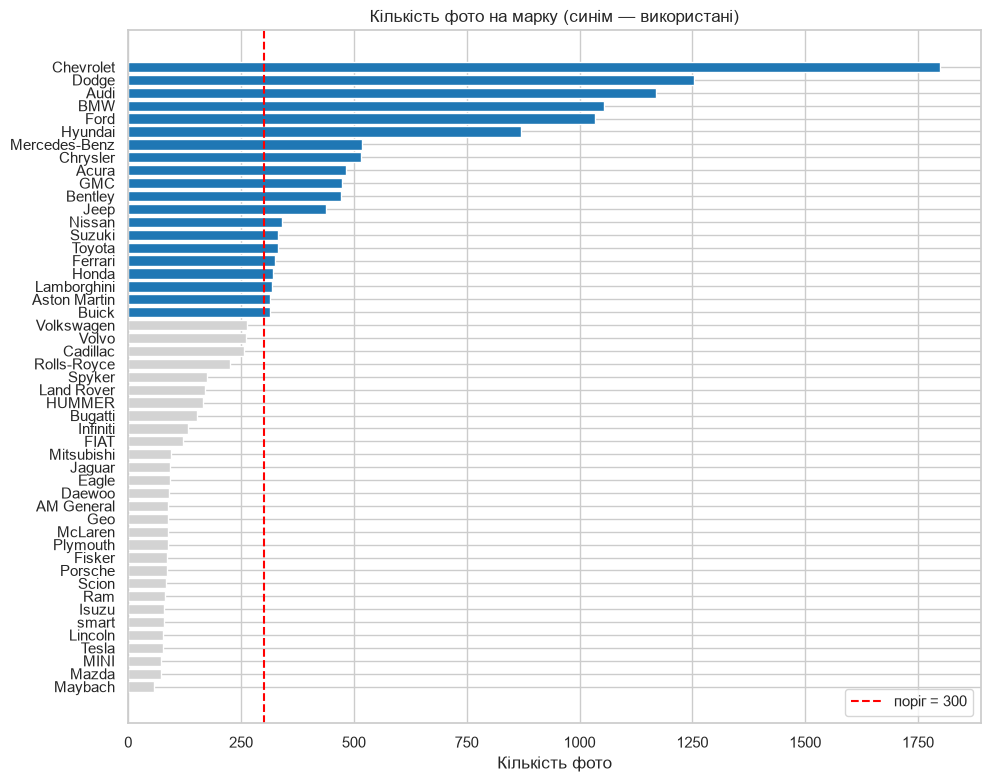

In [4]:
fig, ax = plt.subplots(figsize=(11, 9))
ax.barh(all_counts["make"], all_counts["images"],
        color=all_counts["kept"].map({True: "tab:blue", False: "lightgray"}))
ax.axvline(C.MIN_IMAGES_PER_BRAND, color="red", ls="--", label=f"поріг = {C.MIN_IMAGES_PER_BRAND}")
ax.invert_yaxis(); ax.set_xlabel("Кількість фото"); ax.legend()
ax.set_title("Кількість фото на марку (синім — використані)")
plt.show()

## 3. Дисбаланс класів і кількість моделей у марці

In [5]:
per_make = meta.groupby("make").agg(images=("id", "count"), car_models=("model", "nunique"))
per_make = per_make.sort_values("images", ascending=False)
print(f"Співвідношення найбільшого та найменшого класу: {per_make['images'].max() / per_make['images'].min():.2f}")
per_make

Співвідношення найбільшого та найменшого класу: 5.73


,images,car_models
make,,
Chevrolet,1799,22
Dodge,1253,15
Audi,1169,14
BMW,1055,13
Ford,1035,12
Hyundai,871,11
Mercedes-Benz,518,6
Chrysler,516,6
Acura,482,6


Chevrolet має в ~5.7 разів більше фото, ніж Buick. Через це accuracy може бути завищеною
за рахунок великих класів, тому основною метрикою обрано **macro F1** (кожна марка має однакову вагу).

Також марки сильно відрізняються кількістю моделей: модель має навчитися впізнавати
спільні риси бренду (решітка радіатора, фари, логотип) у різних кузовах.

## 4. Перевірка стратифікації

In [6]:
shares = pd.crosstab(meta["make"], meta["split"], normalize="columns")[["train", "val", "test"]]
print(f"Максимальне відхилення частки класу між вибірками: {(shares.max(1) - shares.min(1)).max():.4f}")
(shares * 100).round(2).head(10)

Максимальне відхилення частки класу між вибірками: 0.0005


/var/folders/m0/vs5dgglx451b0m__nmv1xyrm0000gn/T/ipykernel_76202/1062130379.py:2: Pandas4Warning: Starting with pandas version 4.0 all arguments of max will be keyword-only.
  print(f"Максимальне відхилення частки класу між вибірками: {(shares.max(1) - shares.min(1)).max():.4f}")
/var/folders/m0/vs5dgglx451b0m__nmv1xyrm0000gn/T/ipykernel_76202/1062130379.py:2: Pandas4Warning: Starting with pandas version 4.0 all arguments of min will be keyword-only.
  print(f"Максимальне відхилення частки класу між вибірками: {(shares.max(1) - shares.min(1)).max():.4f}")


split,train,val,test
make,,,
Acura,3.80,3.84,3.78
Aston Martin,2.48,2.47,2.47
Audi,9.22,9.20,9.25
BMW,8.31,8.31,8.36
Bentley,3.72,3.73,3.73
Buick,2.48,2.47,2.47
Chevrolet,14.18,14.20,14.19
Chrysler,4.07,4.05,4.10
Dodge,9.88,9.88,9.88


Частка кожної марки в train, val і test практично однакова — розбиття стратифіковане коректно.

## 5. Приклади зображень

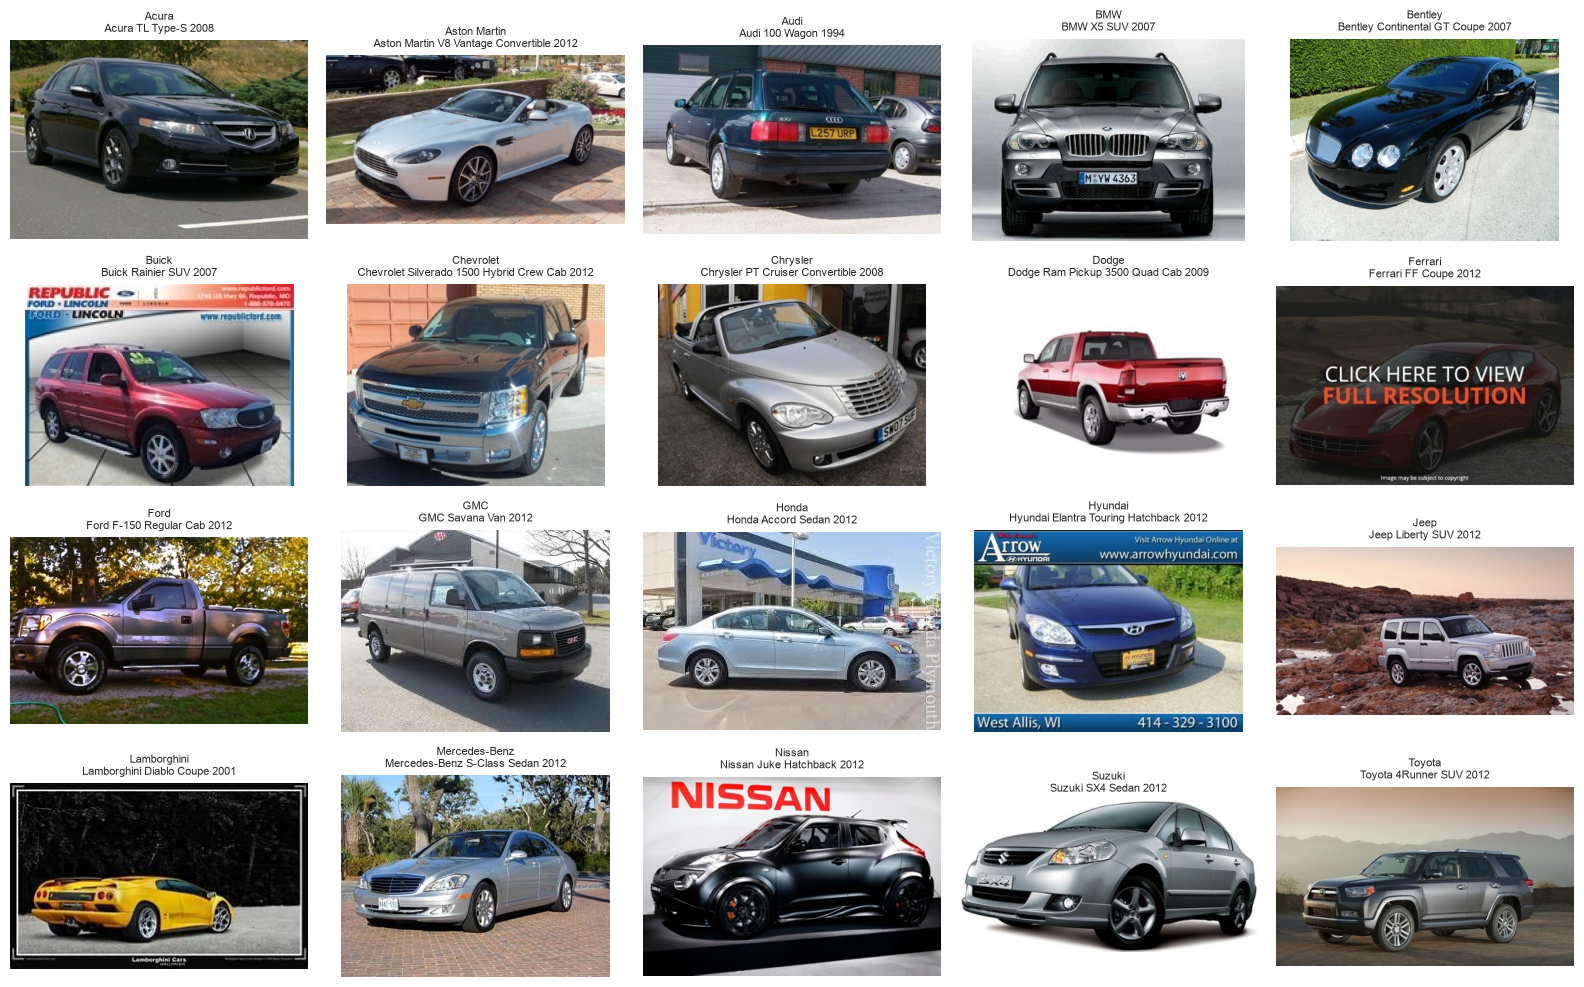

In [7]:
makes = sorted(meta["make"].unique())
train = meta[meta["split"] == "train"]
fig, axes = plt.subplots(4, 5, figsize=(16, 10))
for ax, make in zip(axes.flat, makes):
    r = train[train["make"] == make].sample(1, random_state=0).iloc[0]
    ax.imshow(Image.open(C.IMAGES_DIR / r["path"])); ax.set_title(f"{make}\n{r['model']}", fontsize=8); ax.axis("off")
plt.tight_layout(); plt.show()

Фото різноманітні: різні ракурси (спереду, ззаду, збоку), фон, освітлення,
є водяні знаки дилерів і текст. Це ускладнює задачу для простих моделей.

## 6. Розміри зображень

In [8]:
meta["aspect"] = meta["width"] / meta["height"]
meta[["width", "height", "aspect"]].describe().round(2)

,width,height,aspect
count,12681.00,12681.00,12681.00
mean,700.72,484.61,1.47
std,453.86,318.96,0.23
min,78.00,53.00,0.59
25%,429.00,291.00,1.33
50%,640.00,426.00,1.34
75%,800.00,540.00,1.51
max,7800.00,5400.00,3.61


Розміри сильно відрізняються (від ~100 до ~8000 пікселів), медіанне співвідношення сторін ≈ 1.5.
Тому всі фото приводяться до єдиного розміру: 192×128 для ознак HOG і 224×224 для нейромереж.

## 7. Ознаки HOG (рівень 1)

HOG описує форму об'єкта через напрямки перепадів яскравості в маленьких клітинках.

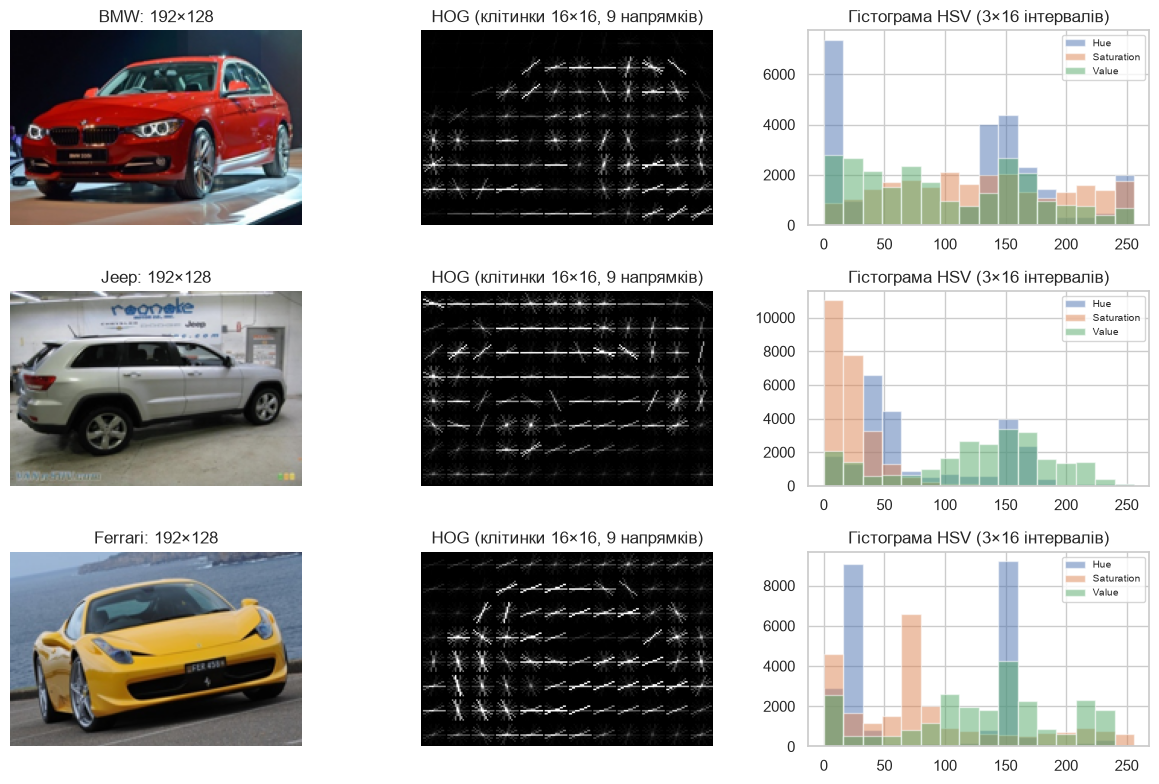

Довжина вектора ознак: 2820


In [9]:
from skimage.feature import hog
from skimage import exposure
from src.features import FEATURE_IMAGE_SIZE, HOG_PARAMS, extract_features

examples = train.groupby("make").sample(1, random_state=1).set_index("make").loc[["BMW", "Jeep", "Ferrari"]]
fig, axes = plt.subplots(3, 3, figsize=(12, 8))
for row, (make, r) in zip(axes, examples.iterrows()):
    img = Image.open(C.IMAGES_DIR / r["path"]).convert("RGB").resize(FEATURE_IMAGE_SIZE)
    gray = np.asarray(img.convert("L"), dtype=np.float32) / 255
    _, hog_img = hog(gray, visualize=True, **HOG_PARAMS)
    hsv = np.asarray(img.convert("HSV"))
    row[0].imshow(img); row[0].set_title(f"{make}: 192×128")
    row[1].imshow(exposure.rescale_intensity(hog_img, in_range=(0, hog_img.max() / 3)), cmap="gray")
    row[1].set_title("HOG (клітинки 16×16, 9 напрямків)")
    for ch, name in enumerate(["Hue", "Saturation", "Value"]):
        row[2].hist(hsv[..., ch].ravel(), bins=16, range=(0, 256), alpha=0.5, label=name)
    row[2].set_title("Гістограма HSV (3×16 інтервалів)"); row[2].legend(fontsize=7)
    row[0].axis("off"); row[1].axis("off")
plt.tight_layout()
plt.savefig(C.FIGURES_DIR / "05_hog_features.png", dpi=130)
plt.show()
print("Довжина вектора ознак:", extract_features(C.IMAGES_DIR / examples.iloc[0]["path"]).shape[0])

## 8. Аугментація (рівні 2–3)

Під час навчання нейромереж кожне фото щоразу випадково змінюється:
обрізка зі збереженням пропорцій авто, віддзеркалення, зміна яскравості/контрасту/насиченості.

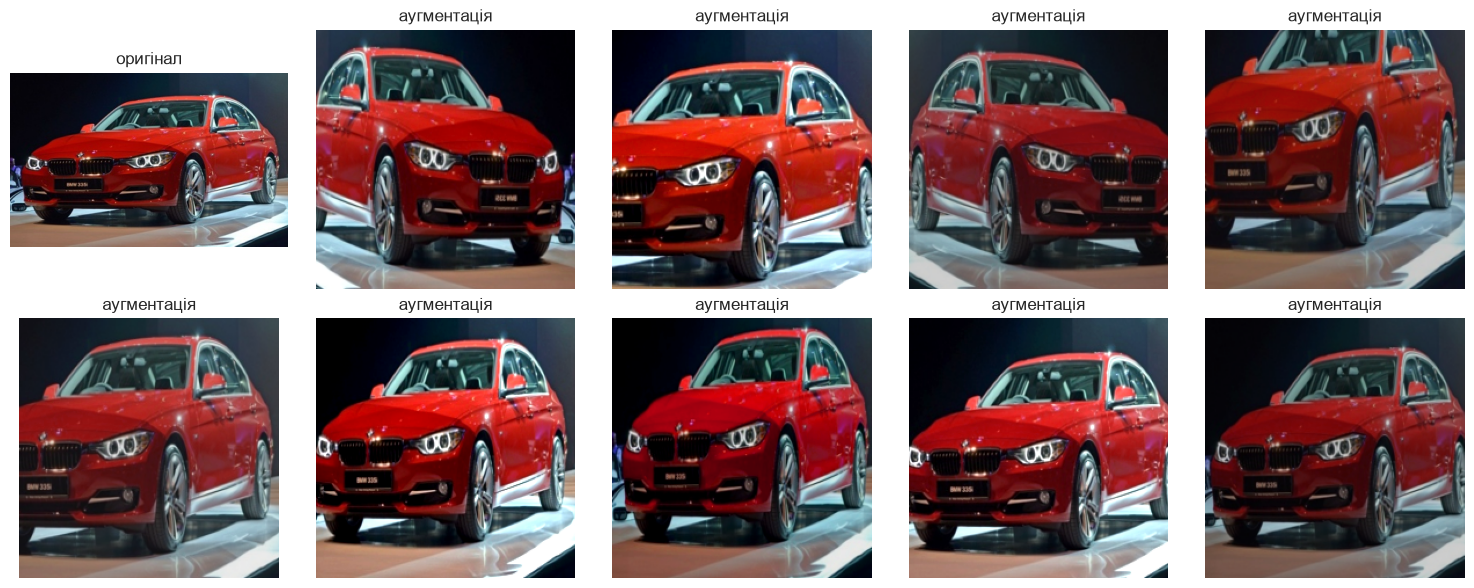

In [10]:
from src.data import build_transforms

train_tf, _ = build_transforms(224, (0, 0, 0), (1, 1, 1))
img = Image.open(C.IMAGES_DIR / examples.loc["BMW", "path"]).convert("RGB")
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes[0, 0].imshow(img); axes[0, 0].set_title("оригінал")
import torch
torch.manual_seed(0)
for ax in axes.flat[1:]:
    ax.imshow(train_tf(img).permute(1, 2, 0).clamp(0, 1)); ax.set_title("аугментація")
for ax in axes.flat: ax.axis("off")
plt.tight_layout()
plt.savefig(C.FIGURES_DIR / "06_augmentations.png", dpi=120)
plt.show()

## Висновки

- Використано 20 марок і 12 681 фото; розбиття 70/15/15 стратифіковане.
- Класи незбалансовані (співвідношення ≈ 5.7), тому основна метрика — macro F1.
- Фото різнорідні за ракурсом, фоном і розміром — задача складна для моделей на ручних ознаках,
  тому очікується значний розрив між класичним ML і нейромережами.